<h1> 10.0 Serialising and normalising data <h1>

In [39]:
class Element:
    def __init__(self, symbol, number):
        self.symbol = symbol
        self.number = number

    def __str__(self):
        return str(self.symbol)


class Molecule:
    def __init__(self, mass):
        self.elements = {}  # Map from element to number of that element in the molecule
        self.mass = mass

    def add_element(self, element, number):
        self.elements[element] = number

    @staticmethod
    def as_subscript(number):
        if number == 1:
            return ""
        if number < 10:
            return "_" + str(number)
        return "_{" + str(number) + "}"

    def __str__(self):
        return "".join(
            [
                str(element) + Molecule.as_subscript(number)
                for element, number in self.elements.items()
            ]
        )


class Reaction:
    def __init__(self):
        self.reactants = {}  # Map from reactants to stoichiometries
        self.products = {}  # Map from products to stoichiometries

    def add_reactant(self, reactant, stoichiometry):
        self.reactants[reactant] = stoichiometry

    def add_product(self, product, stoichiometry):
        self.products[product] = stoichiometry

    @staticmethod
    def print_if_not_one(number):
        if number == 1:
            return ""
        return str(number)

    @staticmethod
    def side_as_string(side):
        return " + ".join(
            [
                Reaction.print_if_not_one(side[molecule]) + str(molecule)
                for molecule in side
            ]
        )

    def __str__(self):
        return (
            Reaction.side_as_string(self.reactants)
            + " \\rightarrow "
            + Reaction.side_as_string(self.products)
        )


class System:
    def __init__(self):
        self.reactions = []

    def add_reaction(self, reaction):
        self.reactions.append(reaction)

    def __str__(self):
        return "\n".join(self.reactions)

In [40]:
c = Element("C", 12)
o = Element("O", 8)
h = Element("H", 1)

co2 = Molecule(44.01)
co2.add_element(c, 1)
co2.add_element(o, 2)

h2o = Molecule(18.01)
h2o.add_element(h, 2)
h2o.add_element(o, 1)

o2 = Molecule(32.00)
o2.add_element(o, 2)

glucose = Molecule(180.16)
glucose.add_element(c, 6)
glucose.add_element(h, 12)
glucose.add_element(o, 6)

combustion = Reaction()
combustion.add_reactant(glucose, 1)
combustion.add_reactant(o2, 6)
combustion.add_product(co2, 6)
combustion.add_product(h2o, 6)

print(combustion)

C_6H_{12}O_6 + 6O_2 \rightarrow 6CO_2 + 6H_2O


In [41]:
from IPython.display import Math, display

display(Math(str(combustion)))

<IPython.core.display.Math object>

In [42]:
%%writefile molecules.csv
# name, elements, numbers

water, H O, 2 1
oxygen, O, 2
carbon_dioxide, C O, 1 2
glucose, C H O, 6 12 6

Overwriting molecules.csv


In [43]:
%%writefile reactions.csv

# name, reactants, products, reactant_stoichiometries, product_stoichiometries

combustion_of_glucose, glucose oxygen, carbon_dioxide water, 1 6, 6 6

Overwriting reactions.csv


In [44]:
%%writefile molecules.csv
# name, element, number

water, H, 2
water, O, 1
oxygen, O, 2
carbon_dioxide, C, 1
carbon_dioxide, O, 2

Overwriting molecules.csv


In [45]:
%%writefile molecules.csv
# name, element, number, molecular_mass, atomic_number

water, H, 2, 18.01, 1
water, O, 1, 18.01, 8
oxygen, O, 2, 32.00, 8

Overwriting molecules.csv


In [46]:
%%writefile molecules.csv
# name, molecular_mass

water, 18.01
oxygen, 32.00

Overwriting molecules.csv


In [47]:
%%writefile atoms.csv

# symbol, atomic number
H, 1
O, 8
C, 6

Overwriting atoms.csv


In [48]:
%%writefile atoms_in_molecules.csv

# rel_number, molecule, symbol, number
0, water, H, 2
1, water, O, 1
2, oxygen, O, 2

Overwriting atoms_in_molecules.csv


<h1> 10.1 Using databases <h1>

In [49]:
import os

try:
    os.remove("molecules.db")
    print("Removing database to start again from scratch")
except FileNotFoundError:
    print("No DB since this notebook was last run")

Removing database to start again from scratch


In [50]:
import sqlalchemy

engine = sqlalchemy.create_engine("sqlite:///molecules.db", echo=True)

In [51]:
from sqlalchemy import Column, Float, Integer, MetaData, String, Table

metadata = MetaData()
molecules = Table(
    "molecules",
    metadata,
    Column("name", String, primary_key=True),
    Column("mass", Float),
)

atoms = Table(
    "atoms",
    metadata,
    Column("symbol", String, primary_key=True),
    Column("number", Integer),
)

In [52]:
from sqlalchemy import ForeignKey, Integer

atoms_in_molecules = Table(
    "atoms_molecules",
    metadata,
    Column("atom", ForeignKey("atoms.symbol")),
    Column("molecule", ForeignKey("molecules.name")),
    Column("number", Integer),
)

In [53]:
metadata.create_all(engine)
print(metadata)

2026-04-26 13:35:50,023 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-26 13:35:50,024 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("molecules")
2026-04-26 13:35:50,024 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-26 13:35:50,025 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("molecules")
2026-04-26 13:35:50,025 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-26 13:35:50,026 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("atoms")
2026-04-26 13:35:50,026 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-26 13:35:50,026 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("atoms")
2026-04-26 13:35:50,027 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-26 13:35:50,027 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("atoms_molecules")
2026-04-26 13:35:50,027 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-26 13:35:50,027 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("atoms_molecules")
2026-04-26 13:35:50,027 INFO sqlalchemy.engine.Eng

In [54]:
engine.echo = False

In [55]:
ins = molecules.insert().values(name="water", mass="18.01")

In [56]:
conn = engine.connect()
conn.execute(ins)

In [57]:
from sqlalchemy.sql import select

s = select([molecules])
result = conn.execute(s)
print(result.fetchone()["mass"])

ArgumentError: Column expression, FROM clause, or other columns clause element expected, got [Table('molecules', MetaData(), Column('name', String(), table=<molecules>, primary_key=True, nullable=False), Column('mass', Float(), table=<molecules>), schema=None)]. Did you mean to say select(Table('molecules', MetaData(), Column('name', String(), table=<molecules>, primary_key=True, nullable=False), Column('mass', Float(), table=<molecules>), schema=None))?

In [58]:
conn.execute(molecules.insert().values(name="oxygen", mass="32.00"))
conn.execute(atoms.insert().values(symbol="O", number=8))
conn.execute(atoms.insert().values(symbol="H", number=1))
conn.execute(atoms_in_molecules.insert().values(molecule="water", atom="O", number=1))
conn.execute(atoms_in_molecules.insert().values(molecule="oxygen", atom="O", number=1))
conn.execute(atoms_in_molecules.insert().values(molecule="water", atom="H", number=2))

In [59]:
result = conn.execute(
    """
    SELECT mass
    FROM   molecules
          JOIN atoms_molecules
            ON molecules.NAME = atoms_molecules.molecule
          JOIN atoms
            ON atoms.symbol = atoms_molecules.atom
    WHERE  atoms.symbol = 'H'
    """
)
print(result.fetchall())

ObjectNotExecutableError: Not an executable object: "\n    SELECT mass\n    FROM   molecules\n          JOIN atoms_molecules\n            ON molecules.NAME = atoms_molecules.molecule\n          JOIN atoms\n            ON atoms.symbol = atoms_molecules.atom\n    WHERE  atoms.symbol = 'H'\n    "

In [60]:
import os

try:
    os.remove("molecules.db")
    print("Removing database to start again from scratch")
except FileNotFoundError:
    print("No DB since this notebook was last run")

Removing database to start again from scratch


In [61]:
import sqlalchemy

engine = sqlalchemy.create_engine("sqlite:///molecules.db")

In [62]:
from sqlalchemy import Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import relationship

Base = declarative_base()


class Element(Base):
    __tablename__ = "atoms"
    symbol = Column(String, primary_key=True)
    number = Column(Integer)
    molecules = relationship("AtomsPerMolecule", backref="atom")

/var/folders/j7/2lnv016s5qn2r5lcrf2bk7080000gn/T/ipykernel_24744/1118890638.py:5: MovedIn20Warning: The ``declarative_base()`` function is now available as sqlalchemy.orm.declarative_base(). (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base = declarative_base()


In [63]:
class Molecule(Base):
    __tablename__ = "molecules"
    name = Column(String, primary_key=True)
    mass = Column(Float)
    atoms = relationship("AtomsPerMolecule", backref="molecule")

In [64]:
class AtomsPerMolecule(Base):
    __tablename__ = "atoms_per_molecule"
    id = Column(Integer, primary_key=True)
    atom_id = Column(None, ForeignKey("atoms.symbol"))
    molecule_id = Column(None, ForeignKey("molecules.name"))
    number = Column(Integer)

In [65]:
Base.metadata.create_all(engine)

In [66]:
engine.echo = False

In [67]:
oxygen = Element(symbol="O", number=8)
hydrogen = Element(symbol="H", number=1)
elements = [oxygen, hydrogen]

In [68]:
water = Molecule(name="water", mass=18.01)
oxygen_m = Molecule(name="oxygen", mass=16.00)
hydrogen_m = Molecule(name="hydrogen", mass=2.02)
molecules = [water, oxygen_m, hydrogen_m]

In [69]:
# Note that we are using the `backref` name to construct the `atom_id` and `molecule_id`.
# These lookup instances of Element and Molecule that are already in our database
amounts = [
    AtomsPerMolecule(atom=oxygen, molecule=water, number=1),
    AtomsPerMolecule(atom=hydrogen, molecule=water, number=2),
    AtomsPerMolecule(atom=oxygen, molecule=oxygen_m, number=2),
    AtomsPerMolecule(atom=hydrogen, molecule=hydrogen_m, number=2),
]

In [70]:
from sqlalchemy.orm import sessionmaker

Session = sessionmaker(bind=engine)
session = Session()

In [71]:
session.bulk_save_objects(elements + molecules + amounts)

In [72]:
oxygen.molecules[0].molecule.name

'water'

In [73]:
session.query(Molecule).all()[0].name

'water'

In [74]:
session.commit()

In [75]:
import pandas
str(session.query(Molecule).statement)

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


'SELECT molecules.name, molecules.mass \nFROM molecules'

In [76]:
from sqlalchemy.dialects import sqlite

stmt = session.query(Molecule).statement
compiled = stmt.compile(
    dialect=sqlite.dialect(),
    compile_kwargs={"literal_binds": True}
)

with session.get_bind().connect() as conn:
    dataframe = pandas.read_sql_query(str(compiled), conn.connection)

/var/folders/j7/2lnv016s5qn2r5lcrf2bk7080000gn/T/ipykernel_24744/1113095277.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframe = pandas.read_sql_query(str(compiled), conn.connection)


In [77]:
dataframe

,name,mass
0,water,18.01
1,oxygen,16.00
2,hydrogen,2.02


In [78]:
print(dataframe.to_csv())

,name,mass
0,water,18.01
1,oxygen,16.0
2,hydrogen,2.02


In [79]:
%%writefile atoms.csv

symbol,number
C,6
N,7

Overwriting atoms.csv


In [80]:
with open("atoms.csv", "r") as f_csv:
    atoms = pandas.read_csv(f_csv)
atoms

,symbol,number
0,C,6
1,N,7


In [81]:
atoms.to_sql("atoms", session.get_bind(), if_exists="append", index=False)

2

In [82]:
session.query(Element).all()[3].number

7

<h1> 10.2 Deserialisation <h1>

In [83]:
class Element:
    def __init__(self, symbol):
        self.symbol = symbol


class Molecule:
    def __init__(self):
        self.elements = {}  # Map from element to number of that element in the molecule

    def add_element(self, element, number):
        self.elements[element] = number

    def to_struct(self):
        return {element.symbol: number for element, number in self.elements.items()}


class Reaction:
    def __init__(self):
        self.reactants = {}  # Map from reactants to stoichiometries
        self.products = {}  # Map from products to stoichiometries

    def add_reactant(self, reactant, stoichiometry):
        self.reactants[reactant] = stoichiometry

    def add_product(self, product, stoichiometry):
        self.products[product] = stoichiometry

    def to_struct(self):
        return {
            "reactants": [x.to_struct() for x in self.reactants],
            "products": [x.to_struct() for x in self.products],
            "stoichiometries": list(self.reactants.values())
            + list(self.products.values()),
        }


class System:
    def __init__(self):
        self.reactions = []

    def add_reaction(self, reaction):
        self.reactions.append(reaction)

    def to_struct(self):
        return [x.to_struct() for x in self.reactions]

In [84]:
c = Element("C")
o = Element("O")
h = Element("H")

co2 = Molecule()
co2.add_element(c, 1)
co2.add_element(o, 2)

h2o = Molecule()
h2o.add_element(h, 2)
h2o.add_element(o, 1)

o2 = Molecule()
o2.add_element(o, 2)

h2 = Molecule()
h2.add_element(h, 2)

glucose = Molecule()
glucose.add_element(c, 6)
glucose.add_element(h, 12)
glucose.add_element(o, 6)

combustion_glucose = Reaction()
combustion_glucose.add_reactant(glucose, 1)
combustion_glucose.add_reactant(o2, 6)
combustion_glucose.add_product(co2, 6)
combustion_glucose.add_product(h2o, 6)

combustion_hydrogen = Reaction()
combustion_hydrogen.add_reactant(h2, 2)
combustion_hydrogen.add_reactant(o2, 1)
combustion_hydrogen.add_product(h2o, 2)

s = System()
s.add_reaction(combustion_glucose)
s.add_reaction(combustion_hydrogen)

s.to_struct()

[{'reactants': [{'C': 6, 'H': 12, 'O': 6}, {'O': 2}],
  'products': [{'C': 1, 'O': 2}, {'H': 2, 'O': 1}],
  'stoichiometries': [1, 6, 6, 6]},
 {'reactants': [{'H': 2}, {'O': 2}],
  'products': [{'H': 2, 'O': 1}],
  'stoichiometries': [2, 1, 2]}]

In [85]:
import yaml

print(yaml.dump(s.to_struct()))

- products:
  - C: 1
    O: 2
  - H: 2
    O: 1
  reactants:
  - C: 6
    H: 12
    O: 6
  - O: 2
  stoichiometries:
  - 1
  - 6
  - 6
  - 6
- products:
  - H: 2
    O: 1
  reactants:
  - H: 2
  - O: 2
  stoichiometries:
  - 2
  - 1
  - 2


In [86]:
class YamlDeSerialisingSystem:
    def __init__(self):
        self.elements = {}
        self.molecules = {}

    def add_element(self, candidate):
        if candidate not in self.elements:
            self.elements[candidate] = Element(candidate)
        return self.elements[candidate]

    def add_molecule(self, candidate):
        if tuple(candidate.items()) not in self.molecules:
            m = Molecule()
            for symbol, number in candidate.items():
                m.add_element(self.add_element(symbol), number)
            self.molecules[tuple(candidate.items())] = m
        return self.molecules[tuple(candidate.items())]

    def parse_system(self, system_dict):
        system = System()
        for reaction in system_dict:
            r = Reaction()
            stoichiometries = reaction["stoichiometries"]
            for molecule in reaction["reactants"]:
                r.add_reactant(self.add_molecule(molecule), stoichiometries.pop(0))
            for molecule in reaction["products"]:
                r.add_product(self.add_molecule(molecule), stoichiometries.pop(0))
            system.add_reaction(r)
        return system

In [87]:
de_serialiser = YamlDeSerialisingSystem()
round_trip = de_serialiser.parse_system(s.to_struct())
round_trip.to_struct()

[{'reactants': [{'C': 6, 'H': 12, 'O': 6}, {'O': 2}],
  'products': [{'C': 1, 'O': 2}, {'H': 2, 'O': 1}],
  'stoichiometries': [1, 6, 6, 6]},
 {'reactants': [{'H': 2}, {'O': 2}],
  'products': [{'H': 2, 'O': 1}],
  'stoichiometries': [2, 1, 2]}]

In [88]:
de_serialiser.elements

{'C': <__main__.Element at 0x12ada8f50>,
 'H': <__main__.Element at 0x12ad80190>,
 'O': <__main__.Element at 0x12ad82e10>}

In [89]:
de_serialiser.molecules

{(('C', 6), ('H', 12), ('O', 6)): <__main__.Molecule at 0x12ace7a90>,
 (('O', 2),): <__main__.Molecule at 0x12ad82bd0>,
 (('C', 1), ('O', 2)): <__main__.Molecule at 0x12ad81d50>,
 (('H', 2), ('O', 1)): <__main__.Molecule at 0x12ad82ed0>,
 (('H', 2),): <__main__.Molecule at 0x12ad80e10>}

In [90]:
list(round_trip.reactions[0].reactants.keys())[1].to_struct()

{'O': 2}

In [91]:
list(round_trip.reactions[1].reactants.keys())[1].to_struct()

{'O': 2}

In [92]:
list(de_serialiser.molecules.keys())

[(('C', 6), ('H', 12), ('O', 6)),
 (('O', 2),),
 (('C', 1), ('O', 2)),
 (('H', 2), ('O', 1)),
 (('H', 2),)]

In [1]:
class YamlSavingSystem:
    def __init__(self):
        self.elements = set()
        self.molecules = set()

    def element_key(self, element):
        return element.symbol

    def molecule_key(self, molecule):
        key = ""
        for element, number in molecule.elements.items():
            key += element.symbol
            key += str(number)
        return key

    def save(self, system):
        for reaction in system.reactions:
            for molecule in reaction.reactants:
                self.molecules.add(molecule)
                for element in molecule.elements:
                    self.elements.add(element)
            for molecule in reaction.products:
                self.molecules.add(molecule)
                for element in molecule.elements:
                    self.elements.add(element)

        result = {
            "elements": [self.element_key(element) for element in self.elements],
            "molecules": {
                self.molecule_key(molecule): {
                    self.element_key(element): number
                    for element, number in molecule.elements.items()
                }
                for molecule in self.molecules
            },
            "reactions": [
                {
                    "reactants": {
                        self.molecule_key(reactant): stoich
                        for reactant, stoich in reaction.reactants.items()
                    },
                    "products": {
                        self.molecule_key(product): stoich
                        for product, stoich in reaction.products.items()
                    },
                }
                for reaction in system.reactions
            ],
        }
        return result

In [2]:
saver = YamlSavingSystem()
print(yaml.dump(saver.save(s)))

NameError: name 'yaml' is not defined

In [3]:
class YamlIntegerKeySavingSystem:
    def __init__(self):
        self.elements = {}
        self.molecules = {}

    def add_element(self, element):
        if element not in self.elements:
            self.elements[element] = len(self.elements)
        return self.elements[element]

    def add_molecule(self, molecule):
        if molecule not in self.molecules:
            self.molecules[molecule] = len(self.molecules)
        return self.molecules[molecule]

    def element_key(self, element):
        return self.elements[element]

    def molecule_key(self, molecule):
        return self.molecules[molecule]

    def save(self, system):
        for reaction in system.reactions:
            for molecule in reaction.reactants:
                self.add_molecule(molecule)
                for element in molecule.elements:
                    self.add_element(element)
            for molecule in reaction.products:
                self.add_molecule(molecule)
                for element in molecule.elements:
                    self.add_element(element)

        result = {
            "elements": [element.symbol for element in self.elements],
            "molecules": {
                self.molecule_key(molecule): {
                    self.element_key(element): number
                    for element, number in molecule.elements.items()
                }
                for molecule in self.molecules
            },
            "reactions": [
                {
                    "reactants": {
                        self.molecule_key(reactant): stoich
                        for reactant, stoich in reaction.reactants.items()
                    },
                    "products": {
                        self.molecule_key(product): stoich
                        for product, stoich in reaction.products.items()
                    },
                }
                for reaction in system.reactions
            ],
        }
        return result

In [4]:
saver = YamlIntegerKeySavingSystem()
print(yaml.dump(saver.save(s)))

NameError: name 'yaml' is not defined

In [5]:
class Element:
    def __init__(self, symbol, id):
        self.symbol = symbol
        self.id = id


class Molecule:
    def __init__(self, id):
        self.elements = {}  # Map from element to number of that element in the molecule
        self.id = id

    def add_element(self, element, number):
        self.elements[element] = number

    def to_struct(self):
        return {element.symbol: number for element, number in self.elements.items()}


class Reaction:
    def __init__(self):
        self.reactants = {}  # Map from reactants to stoichiometries
        self.products = {}  # Map from products to stoichiometries

    def add_reactant(self, reactant, stoichiometry):
        self.reactants[reactant] = stoichiometry

    def add_product(self, product, stoichiometry):
        self.products[product] = stoichiometry

    def to_struct(self):
        return {
            "reactants": [x.to_struct() for x in self.reactants],
            "products": [x.to_struct() for x in self.products],
            "stoichiometries": list(self.reactants.values())
            + list(self.products.values()),
        }


class System:  # This will be our factory
    def __init__(self):
        self.reactions = []
        self.elements = []
        self.molecules = []

    def add_element(self, symbol):
        new_element = Element(symbol, len(self.elements))
        self.elements.append(new_element)
        return new_element

    def add_molecule(self):
        new_molecule = Molecule(len(self.molecules))
        self.molecules.append(new_molecule)
        return new_molecule

    def add_reaction(self):
        new_reaction = Reaction()
        self.reactions.append(new_reaction)
        return new_reaction

    def save(self):

        result = {
            "elements": [element.symbol for element in self.elements],
            "molecules": {
                molecule.id: {
                    element.id: number for element, number in molecule.elements.items()
                }
                for molecule in self.molecules
            },
            "reactions": [
                {
                    "reactants": {
                        reactant.id: stoich
                        for reactant, stoich in reaction.reactants.items()
                    },
                    "products": {
                        product.id: stoich
                        for product, stoich in reaction.products.items()
                    },
                }
                for reaction in self.reactions
            ],
        }

        return result

In [6]:
s2 = System()

c = s2.add_element("C")
o = s2.add_element("O")
h = s2.add_element("H")

co2 = s2.add_molecule()
co2.add_element(c, 1)
co2.add_element(o, 2)

h2o = s2.add_molecule()
h2o.add_element(h, 2)
h2o.add_element(o, 1)

o2 = s2.add_molecule()
o2.add_element(o, 2)

h2 = s2.add_molecule()
h2.add_element(h, 2)

glucose = s2.add_molecule()
glucose.add_element(c, 6)
glucose.add_element(h, 12)
glucose.add_element(o, 6)

combustion_glucose = s2.add_reaction()
combustion_glucose.add_reactant(glucose, 1)
combustion_glucose.add_reactant(o2, 6)
combustion_glucose.add_product(co2, 6)
combustion_glucose.add_product(h2o, 6)
combustion_hydrogen = s2.add_reaction()
combustion_hydrogen.add_reactant(h2, 2)
combustion_hydrogen.add_reactant(o2, 1)
combustion_hydrogen.add_product(h2o, 2)

In [7]:
s2.save()

{'elements': ['C', 'O', 'H'],
 'molecules': {0: {0: 1, 1: 2},
  1: {2: 2, 1: 1},
  2: {1: 2},
  3: {2: 2},
  4: {0: 6, 2: 12, 1: 6}},
 'reactions': [{'reactants': {4: 1, 2: 6}, 'products': {0: 6, 1: 6}},
  {'reactants': {3: 2, 2: 1}, 'products': {1: 2}}]}

In [8]:
import yaml
print(yaml.dump(s2.save()))

elements:
- C
- O
- H
molecules:
  0:
    0: 1
    1: 2
  1:
    1: 1
    2: 2
  2:
    1: 2
  3:
    2: 2
  4:
    0: 6
    1: 6
    2: 12
reactions:
- products:
    0: 6
    1: 6
  reactants:
    2: 6
    4: 1
- products:
    1: 2
  reactants:
    2: 1
    3: 2


<h1> 10.3 Binary formats <h1>

In [9]:
class FakeBinarySavingSystem:
    # Pretend binary-style writing to a list to make it easier to read at first.
    def save(self, system, buffer):
        buffer.append(len(system.elements))
        for element in system.elements:
            buffer.append(element.symbol)

        buffer.append(len(system.molecules))
        for molecule in system.molecules:
            buffer.append(len(molecule.elements))
            for element, number in molecule.elements.items():
                buffer.append(element.id)
                buffer.append(number)

        buffer.append(len(system.reactions))
        for reaction in system.reactions:
            buffer.append(len(reaction.reactants))
            for reactant, stoich in reaction.reactants.items():
                buffer.append(reactant.id)
                buffer.append(stoich)
            buffer.append(len(reaction.products))
            for product, stoich in reaction.products.items():
                buffer.append(product.id)
                buffer.append(stoich)

In [11]:
characterarray = []
FakeBinarySavingSystem().save(s2, characterarray)
characterarray

[3,
 'C',
 'O',
 'H',
 5,
 2,
 0,
 1,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 2,
 3,
 0,
 6,
 2,
 12,
 1,
 6,
 2,
 2,
 4,
 1,
 2,
 6,
 2,
 0,
 6,
 1,
 6,
 2,
 3,
 2,
 2,
 1,
 1,
 1,
 2]

In [12]:
# First, turn symbol characters to equivalent integers (ascii)
intarray = [x.encode("ascii")[0] if isinstance(x, str) else x for x in characterarray]
intarray

[3,
 67,
 79,
 72,
 5,
 2,
 0,
 1,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 2,
 3,
 0,
 6,
 2,
 12,
 1,
 6,
 2,
 2,
 4,
 1,
 2,
 6,
 2,
 0,
 6,
 1,
 6,
 2,
 3,
 2,
 2,
 1,
 1,
 1,
 2]

In [13]:
bytearray(intarray)

bytearray(b'\x03COH\x05\x02\x00\x01\x01\x02\x02\x02\x02\x01\x01\x01\x01\x02\x01\x02\x02\x03\x00\x06\x02\x0c\x01\x06\x02\x02\x04\x01\x02\x06\x02\x00\x06\x01\x06\x02\x03\x02\x02\x01\x01\x01\x02')

In [14]:
with open("system.mol", "wb") as binfile:
    binfile.write(bytearray(intarray))

In [15]:
import xdrlib


class XDRSavingSystem(System):
    def __init__(self, system):
        super().__init__()
        # Shallow Copy constructor
        self.elements = system.elements
        self.reactions = system.reactions
        self.molecules = system.molecules
        self.buffer = xdrlib.Packer()

    def _pack_pair(self, item):
        self.buffer.pack_int(item[0].id)
        self.buffer.pack_int(item[1])

    def _pack_molecule(self, mol):
        self.buffer.pack_array(mol.elements.items(), self._pack_pair)

    def _pack_reaction(self, reaction):
        self.buffer.pack_array(reaction.reactants.items(), self._pack_pair)
        self.buffer.pack_array(reaction.products.items(), self._pack_pair)

    def save(self):
        el_symbols = list(map(lambda x: x.symbol.encode("utf-8"), self.elements))
        # Note that pack_array AUTOMATICALLY packs the length of the array first!
        self.buffer.pack_array(el_symbols, self.buffer.pack_string)
        self.buffer.pack_array(self.molecules, self._pack_molecule)
        self.buffer.pack_array(self.reactions, self._pack_reaction)
        return self.buffer

/var/folders/j7/2lnv016s5qn2r5lcrf2bk7080000gn/T/ipykernel_29723/2559781716.py:1: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [16]:
xdrsys = XDRSavingSystem(s2)
xdrbuffer = xdrsys.save()
xdrbuffer.get_buffer()

b'\x00\x00\x00\x03\x00\x00\x00\x01C\x00\x00\x00\x00\x00\x00\x01O\x00\x00\x00\x00\x00\x00\x01H\x00\x00\x00\x00\x00\x00\x05\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00\x06\x00\x00\x00\x02\x00\x00\x00\x0c\x00\x00\x00\x01\x00\x00\x00\x06\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x04\x00\x00\x00\x01\x00\x00\x00\x02\x00\x00\x00\x06\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x06\x00\x00\x00\x01\x00\x00\x00\x06\x00\x00\x00\x02\x00\x00\x00\x03\x00\x00\x00\x02\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x02'

In [17]:
import h5py
import numpy as np


class HDF5SavingSystem(System):
    def __init__(self, system):
        super().__init__()
        # Shallow Copy constructor
        self.elements = system.elements
        self.reactions = system.reactions
        self.molecules = system.molecules

    def element_symbols(self):
        return list(map(lambda x: x.symbol.encode("ascii"), self.elements))

    def molecule_matrix(self):
        molecule_matrix = np.zeros((len(self.elements), len(self.molecules)), dtype=int)

        for molecule in self.molecules:
            for element, n in molecule.elements.items():
                molecule_matrix[element.id, molecule.id] = n

        return molecule_matrix

    def reaction_matrix(self):
        reaction_matrix = np.zeros(
            (len(self.molecules), len(self.reactions)), dtype=int
        )

        for i, reaction in enumerate(self.reactions):
            for reactant, n in reaction.reactants.items():
                reaction_matrix[reactant.id, i] = -1 * n

            for product, n in reaction.products.items():
                reaction_matrix[product.id, i] = n

        return reaction_matrix

    def write(self, filename):
        hdf = h5py.File(filename, "w")
        string_type = h5py.special_dtype(vlen=bytes)
        hdf.create_dataset(
            "symbols", (len(self.elements), 1), string_type, self.element_symbols()
        )
        hdf.create_dataset("molecules", data=self.molecule_matrix())
        hdf.create_dataset("reactions", data=self.reaction_matrix())
        hdf.close()

In [18]:
saver = HDF5SavingSystem(s2)

In [19]:
saver.element_symbols()

[b'C', b'O', b'H']

In [20]:
saver.molecule_matrix()

array([[ 1,  0,  0,  0,  6],
       [ 2,  1,  2,  0,  6],
       [ 0,  2,  0,  2, 12]])

In [21]:
saver.reaction_matrix()

array([[ 6,  0],
       [ 6,  2],
       [-6, -1],
       [ 0, -2],
       [-1,  0]])

In [22]:
saver.write("foo.hdf5")

In [23]:
with open("foo.hdf5", "rb") as f_in:
    bytes = f_in.read()
bytes[0:100]

b'\x89HDF\r\n\x1a\n\x00\x00\x00\x00\x00\x08\x08\x00\x04\x00\x10\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xf8\x18\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\x00\x00\x00\x00\x00\x00\x00\x00`\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x88\x00\x00\x00\x00\x00\x00\x00\xa8\x02\x00\x00\x00\x00\x00\x00\x01\x00\x01\x00'

In [24]:
hdf_load = h5py.File("foo.hdf5")

In [25]:
np.array(hdf_load["reactions"])

array([[ 6,  0],
       [ 6,  2],
       [-6, -1],
       [ 0, -2],
       [-1,  0]])

<h1> 10.4 Markup Languages <h1>

In [26]:
%%writefile system.xml
<?xml version="1.0" encoding="UTF-8"?>
<system>
    <reaction>
        <reactants>
            <molecule stoichiometry="1">
                <atom symbol="C" number="6"/>
                <atom symbol="H" number="12"/>
                <atom symbol="O" number="6"/>
            </molecule>
            <molecule stoichiometry="6">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="6">
                <atom symbol="C" number="1"/>
                <atom symbol="O" number="2"/>
            </molecule>
            <molecule stoichiometry="6">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
    <reaction>
        <reactants>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
            </molecule>
            <molecule stoichiometry="1">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
</system>    

Writing system.xml


In [27]:
from lxml import etree

with open("system.xml", "r") as xmlfile:
    tree = etree.parse(xmlfile)
print(etree.tostring(tree, pretty_print=True, encoding=str))

<system>
    <reaction>
        <reactants>
            <molecule stoichiometry="1">
                <atom symbol="C" number="6"/>
                <atom symbol="H" number="12"/>
                <atom symbol="O" number="6"/>
            </molecule>
            <molecule stoichiometry="6">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="6">
                <atom symbol="C" number="1"/>
                <atom symbol="O" number="2"/>
            </molecule>
            <molecule stoichiometry="6">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
    <reaction>
        <reactants>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
            </molecule>
            <molecule stoichiometry="1">
                <atom symbol="O" number="2"/>
            </mole

In [28]:
tree.getroot()[0][0][1].attrib["stoichiometry"]

'6'

In [29]:
# For all molecules
# ... with a child atom whose number attribute is '1'
# ... return the symbol attribute of that child
tree.xpath("//molecule/atom[@number='1']/@symbol")

['C', 'O', 'O']

In [30]:
%%writefile xmltotex.xsl

<xsl:stylesheet version="2.0" xmlns:xsl="http://www.w3.org/1999/XSL/Transform">
    <xsl:output method="xml" indent="yes" omit-xml-declaration="yes" />
        
    <!-- Decompose reaction into "reactants \rightarrow products" -->
    <xsl:template match="//reaction">
        <xsl:apply-templates select="reactants"/>
        <xsl:text> \rightarrow </xsl:text>
        <xsl:apply-templates select="products"/>
        <xsl:text>\\&#xa;</xsl:text>
    </xsl:template>
        
    <!-- For a molecule anywhere except the first position write " + " and the number of molecules-->
    <xsl:template match="//molecule[position()!=1]">
        <xsl:text> + </xsl:text>
        <xsl:apply-templates select="@stoichiometry"/>
        <xsl:apply-templates/>
    </xsl:template>

    <!-- For a molecule in first position write the number of molecules -->
    <xsl:template match="//molecule[position()=1]">
        <xsl:apply-templates select="@stoichiometry"/>
        <xsl:apply-templates/>
    </xsl:template>

    <!-- If the stoichiometry is one then ignore it -->
    <xsl:template match="@stoichiometry[.='1']"/>
    
    <!-- Otherwise, use the default template for attributes, which is just to copy value -->
    
    <!-- Decompose element into "symbol number" -->
    <xsl:template match="//atom">
        <xsl:value-of select="@symbol"/>
        <xsl:apply-templates select="@number"/>
    </xsl:template>
        
    <!-- If the number of elements/molecules is one then ignore it -->        
    <xsl:template match="@number[.=1]"/>
    
    <!-- ... otherwise replace it with "_ value" -->        
    <xsl:template match="@number[.!=1][10>.]">
        <xsl:text>_</xsl:text>
        <xsl:value-of select="."/>
    </xsl:template>
        
    <!-- If a number is greater than 10 then wrap it in "{}" -->        
    <xsl:template match="@number[.!=1][.>9]">
        <xsl:text>_{</xsl:text>
        <xsl:value-of select="."/>
        <xsl:text>}</xsl:text>          
    </xsl:template>
        
    <!-- Do not copy input whitespace to output -->
    <xsl:template match="text()" />
</xsl:stylesheet>

Writing xmltotex.xsl


In [31]:
with open("xmltotex.xsl") as xslfile:
    transform_xsl = xslfile.read()
transform = etree.XSLT(etree.XML(transform_xsl))

In [32]:
print(str(transform(tree)))

C_6H_{12}O_6 + 6O_2 \rightarrow 6CO_2 + 6H_2O\\
2H_2 + O_2 \rightarrow 2H_2O\\


In [33]:
%%writefile reactions.xsd

<xs:schema xmlns:xs="http://www.w3.org/2001/XMLSchema">

<xs:element name="atom">
    <xs:complexType>
        <xs:attribute name="symbol" type="xs:string"/>
        <xs:attribute name="number" type="xs:integer"/>
    </xs:complexType>
</xs:element>
    
<xs:element name="molecule">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="atom" maxOccurs="unbounded"/>
        </xs:sequence>
        <xs:attribute name="stoichiometry" type="xs:integer"/>
    </xs:complexType>
</xs:element>
    
<xs:element name="reaction">
    <xs:complexType>
        <xs:sequence>
            <xs:element name="reactants">
                <xs:complexType>
                    <xs:sequence>
                        <xs:element ref="molecule" maxOccurs="unbounded"/>
                    </xs:sequence>
                </xs:complexType>
            </xs:element>
            <xs:element name="products">
                <xs:complexType>
                    <xs:sequence>
                        <xs:element ref="molecule" maxOccurs="unbounded"/>
                    </xs:sequence>
                </xs:complexType>
            </xs:element>
        </xs:sequence>
    </xs:complexType>
</xs:element>

<xs:element name="system">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="reaction" maxOccurs="unbounded"/>
        </xs:sequence>
    </xs:complexType>
</xs:element>
    
</xs:schema>

Writing reactions.xsd


In [34]:
with open("reactions.xsd") as xsdfile:
    schema_xsd = xsdfile.read()
schema = etree.XMLSchema(etree.XML(schema_xsd))

In [35]:
parser = etree.XMLParser(schema=schema)

In [36]:
with open("system.xml") as xmlfile:
    tree = etree.parse(xmlfile, parser)
# For all atoms return their symbol attribute
tree.xpath("//atom/@symbol")

['C', 'H', 'O', 'O', 'C', 'O', 'H', 'O', 'H', 'O', 'H', 'O']

In [37]:
%%writefile invalid_system.xml

<system>
    <reaction>
        <reactants>
            <molecule stoichiometry="two">
                <atom symbol="H" number="2"/>
            </molecule>
            <molecule stoichiometry="1">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
</system>

Writing invalid_system.xml


In [38]:
try:
    with open("invalid_system.xml") as xmlfile:
        tree = etree.parse(xmlfile, parser)
    tree.xpath("//element//@symbol")
except etree.XMLSyntaxError as e:
    print(e)

Element 'molecule', attribute 'stoichiometry': 'two' is not a valid value of the atomic type 'xs:integer'. (<string>, line 0)


<h1> 10.5 Larger datasets - beyond pandas and CSV <h1>

In [44]:
import pandas as pd

df = pd.read_csv("molecules.csv")
df.head()

,# name,molecular_mass
0,water,18.01
1,oxygen,32.00


<h1> 10.6 Processing in parallel <h1>

In [45]:
def mapper(input_filename):
    with open(input_filename) as inputfile:
        # split the text on spaces
        words = inputfile.read().split(" ")
        # use list comprehension to output a list of {word: [1]} dicts
        output = [{word.strip(): [1]} for word in sorted(words)]
        return output

In [46]:
def shuffler(word_dicts):
    output_dict = {}
    for word_dict in word_dicts:
        for k, v in word_dict.items():
            if not k in output_dict.keys():
                output_dict[k] = []
            output_dict[k] += v
    return [{k: v} for k, v in output_dict.items()]

In [47]:
def reducer(word_dict):
    return {k: sum(v) for k, v in word_dict.items()}

In [48]:
from dask.distributed import Client

client = Client()  # or Client("<scheduler URL>") for remote cluster
client

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently instal

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:54157,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:54168,Total threads: 2
Dashboard: http://127.0.0.1:54170/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:54160,


<h1> 10.7 Geospatial data <h1>

In [56]:
import requests

url = "https://archive.unidata.ucar.edu/software/netcdf/examples/ECMWF_ERA-40_subset.nc"
filename = url.split("/")[-1]
r = requests.get(url, allow_redirects=True)
with open(filename, "wb") as saved_file:
    saved_file.write(r.content)

In [57]:
import netCDF4 as nc

ds = nc.Dataset(filename)
ds

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    Conventions: CF-1.0
    history: 2004-09-15 17:04:29 GMT by mars2netcdf-0.92
    dimensions(sizes): longitude(144), latitude(73), time(62)
    variables(dimensions): float32 longitude(longitude), float32 latitude(latitude), int32 time(time), int16 tcw(time, latitude, longitude), int16 tcwv(time, latitude, longitude), int16 lsp(time, latitude, longitude), int16 cp(time, latitude, longitude), int16 msl(time, latitude, longitude), int16 blh(time, latitude, longitude), int16 tcc(time, latitude, longitude), int16 p10u(time, latitude, longitude), int16 p10v(time, latitude, longitude), int16 p2t(time, latitude, longitude), int16 p2d(time, latitude, longitude), int16 e(time, latitude, longitude), int16 lcc(time, latitude, longitude), int16 mcc(time, latitude, longitude), int16 hcc(time, latitude, longitude), int16 tco3(time, latitude, longitude), int16 tp(time, latitude, longitude)
    groups: 

In [58]:
for dim in ds.dimensions.values():
    print(dim)

"<class 'netCDF4.Dimension'>": name = 'longitude', size = 144
"<class 'netCDF4.Dimension'>": name = 'latitude', size = 73
"<class 'netCDF4.Dimension'>" (unlimited): name = 'time', size = 62


In [59]:
lats = ds.variables["latitude"][:]
lons = ds.variables["longitude"][:]
tco3 = ds.variables["tco3"][0, :, :]

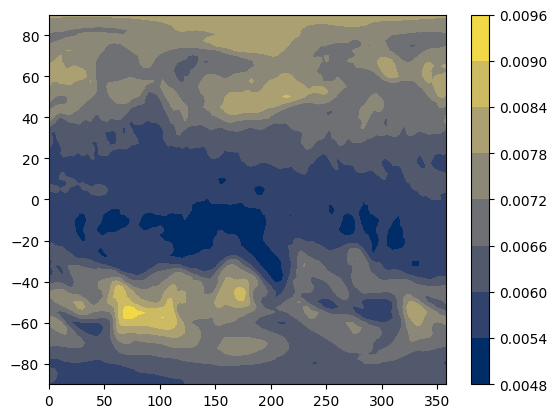

In [60]:
import matplotlib.pyplot as plt
import numpy as np

plt.set_cmap("cividis")  # use a CVD-friendly palette

x, y = np.meshgrid(lons, lats)
plt.contourf(x, y, tco3)
plt.colorbar()

<h1> 10.x.0 (OPTIONAL): Domain specific languages <h1>

In [61]:
%%writefile system.py


class Element:
    def __init__(self, symbol):
        self.symbol = symbol

    def __str__(self):
        return str(self.symbol)


class Molecule:
    def __init__(self):
        self.elements = {}  # Map from element to number of that element in the molecule

    def add_element(self, element, number):
        if not isinstance(element, Element):
            element = Element(element)
        self.elements[element] = number

    @staticmethod
    def as_subscript(number):
        if number == 1:
            return ""
        if number < 10:
            return "_" + str(number)
        return "_{" + str(number) + "}"

    def __str__(self):
        return "".join(
            [
                str(element) + Molecule.as_subscript(self.elements[element])
                for element in self.elements
            ]
        )


class Side:
    def __init__(self):
        self.molecules = {}

    def add(self, reactant, stoichiometry):
        self.molecules[reactant] = stoichiometry

    @staticmethod
    def print_if_not_one(number):
        if number == 1:
            return ""
        else:
            return str(number)

    def __str__(self):
        return " + ".join(
            [
                Side.print_if_not_one(self.molecules[molecule]) + str(molecule)
                for molecule in self.molecules
            ]
        )


class Reaction:
    def __init__(self):
        self.reactants = Side()
        self.products = Side()

    def __str__(self):
        return str(self.reactants) + " \\rightarrow " + str(self.products)


class System:
    def __init__(self):
        self.reactions = []

    def add_reaction(self, reaction):
        self.reactions.append(reaction)

    def __str__(self):
        return "\\\\ \n".join(map(str, self.reactions))

Writing system.py


In [62]:
from system import Element, Molecule, Reaction, System

s2 = System()

c = Element("C")
o = Element("O")
h = Element("H")

co2 = Molecule()
co2.add_element(c, 1)
co2.add_element(o, 2)

h2o = Molecule()
h2o.add_element(h, 2)
h2o.add_element(o, 1)

o2 = Molecule()
o2.add_element(o, 2)

h2 = Molecule()
h2.add_element(h, 2)

glucose = Molecule()
glucose.add_element(c, 6)
glucose.add_element(h, 12)
glucose.add_element(o, 6)

combustion_glucose = Reaction()
combustion_glucose.reactants.add(glucose, 1)
combustion_glucose.reactants.add(o2, 6)
combustion_glucose.products.add(co2, 6)
combustion_glucose.products.add(h2o, 6)
s2.add_reaction(combustion_glucose)


combustion_hydrogen = Reaction()
combustion_hydrogen.reactants.add(h2, 2)
combustion_hydrogen.reactants.add(o2, 1)
combustion_hydrogen.products.add(h2o, 2)
s2.add_reaction(combustion_hydrogen)

print(s2)

C_6H_{12}O_6 + 6O_2 \rightarrow 6CO_2 + 6H_2O\\ 
2H_2 + O_2 \rightarrow 2H_2O


In [63]:
from IPython.display import Math, display

display(Math(str(s2)))

<IPython.core.display.Math object>

In [64]:
%%writefile lexreactions.py

from ply import lex

tokens = (
    "ELEMENT",
    "NUMBER",
    "SUBSCRIPT",
    "LBRACE",
    "RBRACE",
    "PLUS",
    "ARROW",
    "NEWLINE",
    "TEXNEWLINE",
)

# Tokens
t_PLUS = r"\+"
t_SUBSCRIPT = r"_"
t_LBRACE = r"\{"
t_RBRACE = r"\}"
t_TEXNEWLINE = r"\\\\"
t_ARROW = r"\\rightarrow"
t_ELEMENT = r"[A-Z][a-z]?"
t_NEWLINE = r"\n+"


def t_NUMBER(t):
    r"\d+"
    t.value = int(t.value)
    return t


t_ignore = " "


def t_error(t):
    print(f"Did not recognise character '{t.value[0]:s}' as part of a valid token")
    t.lexer.skip(1)


# Build the lexer
lexer = lex.lex()

Writing lexreactions.py


In [65]:
from lexreactions import lexer  
tokens = []
lexer.input(str(s2))
while True:
    tok = lexer.token()
    if not tok:
        break  # No more input
    tokens.append(tok)
    
print(str(s2))

C_6H_{12}O_6 + 6O_2 \rightarrow 6CO_2 + 6H_2O\\ 
2H_2 + O_2 \rightarrow 2H_2O


In [66]:
tokens

[LexToken(ELEMENT,'C',1,0),
 LexToken(SUBSCRIPT,'_',1,1),
 LexToken(NUMBER,6,1,2),
 LexToken(ELEMENT,'H',1,3),
 LexToken(SUBSCRIPT,'_',1,4),
 LexToken(LBRACE,'{',1,5),
 LexToken(NUMBER,12,1,6),
 LexToken(RBRACE,'}',1,8),
 LexToken(ELEMENT,'O',1,9),
 LexToken(SUBSCRIPT,'_',1,10),
 LexToken(NUMBER,6,1,11),
 LexToken(PLUS,'+',1,13),
 LexToken(NUMBER,6,1,15),
 LexToken(ELEMENT,'O',1,16),
 LexToken(SUBSCRIPT,'_',1,17),
 LexToken(NUMBER,2,1,18),
 LexToken(ARROW,'\\rightarrow',1,20),
 LexToken(NUMBER,6,1,32),
 LexToken(ELEMENT,'C',1,33),
 LexToken(ELEMENT,'O',1,34),
 LexToken(SUBSCRIPT,'_',1,35),
 LexToken(NUMBER,2,1,36),
 LexToken(PLUS,'+',1,38),
 LexToken(NUMBER,6,1,40),
 LexToken(ELEMENT,'H',1,41),
 LexToken(SUBSCRIPT,'_',1,42),
 LexToken(NUMBER,2,1,43),
 LexToken(ELEMENT,'O',1,44),
 LexToken(TEXNEWLINE,'\\\\',1,45),
 LexToken(NEWLINE,'\n',1,48),
 LexToken(NUMBER,2,1,49),
 LexToken(ELEMENT,'H',1,50),
 LexToken(SUBSCRIPT,'_',1,51),
 LexToken(NUMBER,2,1,52),
 LexToken(PLUS,'+',1,54),
 LexTok

In [67]:
lexer.input("""2H_2 + O_2 \\leftarrow 2H_2O""")
while True:
    tok = lexer.token()
    if not tok:
        break  # No more input
    print(tok)

LexToken(NUMBER,2,1,0)
LexToken(ELEMENT,'H',1,1)
LexToken(SUBSCRIPT,'_',1,2)
LexToken(NUMBER,2,1,3)
LexToken(PLUS,'+',1,5)
LexToken(ELEMENT,'O',1,7)
LexToken(SUBSCRIPT,'_',1,8)
LexToken(NUMBER,2,1,9)
Did not recognise character '\' as part of a valid token
Did not recognise character 'l' as part of a valid token
Did not recognise character 'e' as part of a valid token
Did not recognise character 'f' as part of a valid token
Did not recognise character 't' as part of a valid token
Did not recognise character 'a' as part of a valid token
Did not recognise character 'r' as part of a valid token
Did not recognise character 'r' as part of a valid token
Did not recognise character 'o' as part of a valid token
Did not recognise character 'w' as part of a valid token
LexToken(NUMBER,2,1,22)
LexToken(ELEMENT,'H',1,23)
LexToken(SUBSCRIPT,'_',1,24)
LexToken(NUMBER,2,1,25)
LexToken(ELEMENT,'O',1,26)


In [68]:
def p_expression_plus(p):
    'expression : expression PLUS term'
    #   ^            ^        ^    ^
    #  p[0]         p[1]     p[2] p[3]
    p[0] = p[1] + p[3]

In [69]:
%%writefile parsereactions.py

# Yacc example
import ply.yacc as yacc

# Get the components of our system
from system import Element, Molecule, Side, Reaction, System

# Get the token map from the lexer.  This is required.
from lexreactions import tokens


def p_expression_system(p):
    "system : equation"
    p[0] = System()
    p[0].add_reaction(p[1])


def p_expression_combine_system(p):
    "system : system TEXNEWLINE NEWLINE equation"
    p[0] = p[1]
    p[0].add_reaction(p[4])


def p_equation(p):
    "equation : side ARROW side"
    p[0] = Reaction()
    p[0].reactants = p[1]
    p[0].products = p[3]


def p_side(p):
    "side : molecules"
    p[0] = Side()
    p[0].add(p[1][0], p[1][1])


def p_molecules(p):
    "molecules : molecule"
    p[0] = (p[1], 1)


def p_stoichiometry(p):
    "molecules : NUMBER molecule"
    p[0] = (p[2], p[1])


def p_plus(p):
    "side : side PLUS molecules"
    p[0] = p[1]
    p[0].add(p[3][0], p[3][1])


def p_molecule(p):
    "molecule : countedelement"
    p[0] = Molecule()
    p[0].add_element(p[1][0], p[1][1])


def p_countedelement(p):
    "countedelement : ELEMENT"
    p[0] = (p[1], 1)


def p_ncountedelement(p):
    "countedelement : ELEMENT atomcount"
    p[0] = (p[1], p[2])


def p_multi_element(p):
    "molecule : molecule countedelement"
    p[0] = p[1]
    p[0].add_element(p[2][0], p[2][1])


def p_multi_atoms(p):
    "atomcount : SUBSCRIPT NUMBER"
    p[0] = int(p[2])


def p_many_atoms(p):
    "atomcount : SUBSCRIPT LBRACE NUMBER RBRACE"
    p[0] = int(p[3])


# Error rule for syntax errors
def p_error(p):
    print("Syntax error in input!")


# Build the parser
parser = yacc.yacc()

Writing parsereactions.py


In [70]:
from parsereactions import parser

roundtrip_system = parser.parse(str(s2))

Generating LALR tables


In [71]:
%%bash
# Read the first 100 lines from the file
head -n 100 parser.out

Created by PLY version 3.11 (http://www.dabeaz.com/ply)

Grammar

Rule 0     S' -> system
Rule 1     system -> equation
Rule 2     system -> system TEXNEWLINE NEWLINE equation
Rule 3     equation -> side ARROW side
Rule 4     side -> molecules
Rule 5     molecules -> molecule
Rule 6     molecules -> NUMBER molecule
Rule 7     side -> side PLUS molecules
Rule 8     molecule -> countedelement
Rule 9     countedelement -> ELEMENT
Rule 10    countedelement -> ELEMENT atomcount
Rule 11    molecule -> molecule countedelement
Rule 12    atomcount -> SUBSCRIPT NUMBER
Rule 13    atomcount -> SUBSCRIPT LBRACE NUMBER RBRACE

Terminals, with rules where they appear

ARROW                : 3
ELEMENT              : 9 10
LBRACE               : 13
NEWLINE              : 2
NUMBER               : 6 12 13
PLUS                 : 7
RBRACE               : 13
SUBSCRIPT            : 12 13
TEXNEWLINE           : 2
error                : 

Nonterminals, with rules where they appear

atomcount            : 10
co

In [72]:
display(Math(str(roundtrip_system)))

<IPython.core.display.Math object>

In [73]:
with open("system.tex", "w") as texfile:
    texfile.write(str(roundtrip_system))

In [74]:
!cat system.tex

C_6H_{12}O_6 + 6O_2 \rightarrow 6CO_2 + 6H_2O\\ 
2H_2 + O_2 \rightarrow 2H_2O

In [75]:
%%writefile reactionsdsl.py


class Element:
    def __init__(self, symbol):
        self.symbol = symbol

    def __str__(self):
        return str(self.symbol)

    def __mul__(self, other):
        """Let Molecule handle the multiplication"""
        return (self / 1) * other

    def __truediv__(self, number):
        """`Element / number => Molecule`"""
        res = Molecule()
        res.add_element(self, number)
        return res


class Molecule:
    def __init__(self):
        self.elements = {}  # Map from element to number of that element in the molecule

    def add_element(self, element, number):
        if not isinstance(element, Element):
            element = Element(element)
        self.elements[element] = number

    @staticmethod
    def as_subscript(number):
        if number == 1:
            return ""
        if number < 10:
            return "_" + str(number)
        return "_{" + str(number) + "}"

    def __str__(self):
        return "".join(
            [
                str(element) + Molecule.as_subscript(self.elements[element])
                for element in self.elements
            ]
        )

    def __mul__(self, other):
        """`Molecule * Element => Molecule`
        `Molecule * Molecule => Molecule`
        """
        if type(other) == Molecule:
            self.elements.update(other.elements)
        else:
            self.add_element(other, 1)
        return self

    def __rmul__(self, stoich):
        """`Number * Molecule => Side`"""
        res = Side()
        res.add(self, stoich)
        return res

    def __add__(self, other):
        """`Molecule + X => Side`"""
        if type(other) == Side:
            other.molecules[self] = 1
            return other
        res = Side()
        res.add(self, 1)
        res.add(other, 1)
        return res


class Side:
    def __init__(self):
        self.molecules = {}

    def add(self, reactant, stoichiometry):
        self.molecules[reactant] = stoichiometry

    @staticmethod
    def print_if_not_one(number):
        if number == 1:
            return ""
        else:
            return str(number)

    def __str__(self):
        return " + ".join(
            [
                Side.print_if_not_one(self.molecules[molecule]) + str(molecule)
                for molecule in self.molecules
            ]
        )

    def __add__(self, other):
        """Side + X => Side"""
        self.molecules.update(other.molecules)
        return self

    def __eq__(self, other):
        res = Reaction()
        res.reactants = self
        res.products = other
        current_system.add_reaction(res)  # Closure!
        return f"Added: '{res}'"


class Reaction:
    def __init__(self):
        self.reactants = Side()
        self.products = Side()

    def __str__(self):
        return str(self.reactants) + " \\rightarrow " + str(self.products)


class System:
    def __init__(self):
        self.reactions = []

    def add_reaction(self, reaction):
        self.reactions.append(reaction)

    def __str__(self):
        return "\\\\ \n".join(map(str, self.reactions))


current_system = System()

Writing reactionsdsl.py


In [76]:
from reactionsdsl import Element, current_system

# Here we add new symbols to the global scope
# This is *not* good practice, we do it here to demonstrate that it is possible to do
for symbol in ("C", "O", "H"):
    globals()[symbol] = Element(symbol)

In [77]:
O / 2 + 2 * (H / 2) == 2 * (H / 2 * O)

"Added: '2H_2 + O_2 \\rightarrow 2H_2O'"

In [78]:
(C / 6) * (H / 12) * (O / 6) + 6 * (O / 2) == 6 * (H / 2 * O) + 6 * (C * (O / 2))

"Added: '6O_2 + C_6H_{12}O_6 \\rightarrow 6H_2O + 6CO_2'"

In [79]:
display(Math(str(current_system)))

<IPython.core.display.Math object>

<h1> 10.x.1 (OPTIONAL): Controlled Vocabularies <h1>

In [80]:
%%writefile system2.xml
<?xml version="1.0" encoding="UTF-8"?>
<system xmlns="http://www.turing.ac.uk/rsd-engineering/schema/reaction">
    <reaction>
        <reactants>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
            </molecule>
            <molecule stoichiometry="1">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
</system>

Writing system2.xml


In [81]:
from lxml import etree

with open("system2.xml") as xmlfile:
    tree = etree.parse(xmlfile)

In [82]:
print(etree.tostring(tree, pretty_print=True, encoding=str))

<system xmlns="http://www.turing.ac.uk/rsd-engineering/schema/reaction">
    <reaction>
        <reactants>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
            </molecule>
            <molecule stoichiometry="1">
                <atom symbol="O" number="2"/>
            </molecule>
        </reactants>
        <products>
            <molecule stoichiometry="2">
                <atom symbol="H" number="2"/>
                <atom symbol="O" number="1"/>
            </molecule>
        </products>
    </reaction>
</system>


In [83]:
tree.xpath("//molecule/atom[@number='1']/@symbol")

[]

In [84]:
namespaces = {"r": "http://www.turing.ac.uk/rsd-engineering/schema/reaction"}

In [85]:
tree.xpath("//r:molecule/r:atom[@number='1']/@symbol", namespaces=namespaces)

['O']

In [86]:
%%writefile system3.xml
<?xml version="1.0" encoding="UTF-8"?>
<r:system xmlns:r="http://www.turing.ac.uk/rsd-engineering/schema/reaction">
    <r:reaction>
        <r:reactants>
            <r:molecule stoichiometry="2">
                <r:atom symbol="H" number="2"/>
            </r:molecule>
            <r:molecule stoichiometry="1">
                <r:atom symbol="O" number="2"/>
            </r:molecule>
        </r:reactants>
        <r:products>
            <r:molecule stoichiometry="2">
                <r:atom symbol="H" number="2"/>
                <r:atom symbol="O" number="1"/>
            </r:molecule>
        </r:products>
    </r:reaction>
</r:system>

Writing system3.xml


In [87]:
%%writefile reactions2.xsd

<xs:schema xmlns:xs="http://www.w3.org/2001/XMLSchema"
    targetNamespace="http://www.turing.ac.uk/rsd-engineering/schema/reaction"
    xmlns:r="http://www.turing.ac.uk/rsd-engineering/schema/reaction">

<xs:element name="atom">
    <xs:complexType>
        <xs:attribute name="symbol" type="xs:string"/>
        <xs:attribute name="number" type="xs:integer"/>
    </xs:complexType>
</xs:element>
    
<xs:element name="molecule">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="r:atom" maxOccurs="unbounded"/>
        </xs:sequence>
        <xs:attribute name="stoichiometry" type="xs:integer"/>
    </xs:complexType>
</xs:element>
    
<xs:element name="reactants">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="r:molecule" maxOccurs="unbounded"/>
        </xs:sequence>
    </xs:complexType>
</xs:element>
    
<xs:element name="products">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="r:molecule" maxOccurs="unbounded"/>
        </xs:sequence>
    </xs:complexType>
</xs:element>    
    
<xs:element name="reaction">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="r:reactants"/>
            <xs:element ref="r:products"/>
        </xs:sequence>
    </xs:complexType>
</xs:element>

<xs:element name="system">
    <xs:complexType>
        <xs:sequence>
            <xs:element ref="r:reaction" maxOccurs="unbounded"/>
        </xs:sequence>
    </xs:complexType>
</xs:element>   
    
</xs:schema>

Writing reactions2.xsd


In [89]:
with open("reactions2.xsd") as xsdfile:
    schema_xsd = xsdfile.read()
schema = etree.XMLSchema(etree.XML(schema_xsd))

In [90]:
parser = etree.XMLParser(schema=schema)

In [92]:
with open("system3.xml") as xmlfile:
    tree = etree.parse(xmlfile, parser)
    print(tree)

In [93]:
%%writefile chemistry_template3.mko
<?xml version="1.0" encoding="UTF-8"?>
<system xmlns="https://www.turing.ac.uk/rsd-engineering/schema/reaction"
        xmlns:dbo="https://dbpedia.org/ontology/">
%for reaction in reactions:
    <reaction>
        <reactants>
        %for molecule in reaction.reactants.molecules:
            <dbo:ChemicalCompound stoichiometry="${reaction.reactants.molecules[molecule]}">
                %for element in molecule.elements:
                    <dbo:ChemicalElement symbol="${element.symbol}"
                                         number="${molecule.elements[element]}"/>
                %endfor
            </dbo:ChemicalCompound>
        %endfor
        </reactants>
        <products>
        %for molecule in reaction.products.molecules:
            <dbo:ChemicalCompound stoichiometry="${reaction.products.molecules[molecule]}">
            %for element in molecule.elements:
                <dbo:ChemicalElement symbol="${element.symbol}"
                                     number="${molecule.elements[element]}"/>
            %endfor
            </dbo:ChemicalCompound>
        %endfor
        </products>
    </reaction>
%endfor
</system>

Writing chemistry_template3.mko


<h1> 10.x.2 (OPTIONAL): Semantic file formats <h1>                 

In [95]:
%%writefile reaction.ttl 

<http://dbpedia.org/ontology/water>
    <http://purl.obolibrary.org/obo/PATO_0001681>
        "18.01528"^^<http://purl.obolibrary.org/obo/UO_0000088>
            .

Writing reaction.ttl


In [96]:
from rdflib import Graph

graph = Graph()
graph.parse("reaction.ttl", format="ttl")

print(len(graph))

for statement in graph:
    print(statement)

1
(rdflib.term.URIRef('http://dbpedia.org/ontology/water'), rdflib.term.URIRef('http://purl.obolibrary.org/obo/PATO_0001681'), rdflib.term.Literal('18.01528', datatype=rdflib.term.URIRef('http://purl.obolibrary.org/obo/UO_0000088')))


In [97]:
print(graph.serialize(format="xml"))

<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:ns1="http://purl.obolibrary.org/obo/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
>
  <rdf:Description rdf:about="http://dbpedia.org/ontology/water">
    <ns1:PATO_0001681 rdf:datatype="http://purl.obolibrary.org/obo/UO_0000088">18.01528</ns1:PATO_0001681>
  </rdf:Description>
</rdf:RDF>


In [98]:
print(graph.serialize(format="ttl"))

@prefix ns1: <http://purl.obolibrary.org/obo/> .

<http://dbpedia.org/ontology/water> ns1:PATO_0001681 "18.01528"^^ns1:UO_0000088 .


In [99]:
%%writefile reaction2.ttl 

@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix dbo: <http://dbpedia.org/ontology/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .

dbo:water obo:PATO_0001681 "18.01528"^^obo:UO_0000088 ;
          disr:containsElement obo:CHEBI_33260 .

Writing reaction2.ttl


In [100]:
graph = Graph()
graph.parse("reaction2.ttl", format="ttl")
print(len(graph))
print(graph.serialize(format="xml"))

2
<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:disr="http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/"
   xmlns:obo="http://purl.obolibrary.org/obo/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
>
  <rdf:Description rdf:about="http://dbpedia.org/ontology/water">
    <obo:PATO_0001681 rdf:datatype="http://purl.obolibrary.org/obo/UO_0000088">18.01528</obo:PATO_0001681>
    <disr:containsElement rdf:resource="http://purl.obolibrary.org/obo/CHEBI_33260"/>
  </rdf:Description>
</rdf:RDF>


In [101]:
%%writefile reaction3.ttl 

@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix dbo: <http://dbpedia.org/ontology/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix xs: <http://www.w3.org/2001/XMLSchema> .

dbo:water obo:PATO_0001681 "18.01528"^^obo:UO_0000088 ;
          disr:containsElement obo:CHEBI_33260 ;
          disr:hasElementQuantity [ 
              disr:countedElement obo:CHEBI_33260 ; 
              disr:countOfElement "2"^^xs:integer
          ] .

Writing reaction3.ttl


In [102]:
%%writefile reaction4.ttl 

@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix dbo: <http://dbpedia.org/ontology/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix xs: <http://www.w3.org/2001/XMLSchema> .

dbo:water obo:PATO_0001681 "18.01528"^^obo:UO_0000088 ;
          disr:containsElement obo:CHEBI_33260 ;
          disr:hasElementQuantity _:a .
                
_:a disr:countedElement obo:CHEBI_33260 ; 
    disr:countOfElement "2"^^xs:integer .

Writing reaction4.ttl


In [103]:
%%writefile chemistry_turtle_template.mko

@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix xs: <http://www.w3.org/2001/XMLSchema> .
        
[ 
%for reaction in reactions:
    disr:hasReaction [
        %for molecule in reaction.reactants.molecules:
            disr:hasReactant [
                %for element in molecule.elements:
                    disr:hasElementQuantity [
                        disr:countedElement [
                            a obo:CHEBI_33259;
                            disr:symbol "${element.symbol}"^^xs:string
                        ] ;
                        disr:countOfElement "${molecule.elements[element]}"^^xs:integer
                    ];
                %endfor
                a obo:CHEBI_23367
            ] ;
        %endfor
        %for molecule in reaction.products.molecules:
            disr:hasProduct [
                %for element in molecule.elements:
                    disr:hasElementQuantity [
                        disr:countedElement [
                            a obo:CHEBI_33259;
                            disr:symbol "${element.symbol}"^^xs:string
                        ] ;
                        disr:countOfElement "${molecule.elements[element]}"^^xs:integer
                    ] ;
                %endfor
                a obo:CHEBI_23367
            ] ;
        %endfor
        a disr:reaction
    ] ;
%endfor
a disr:system
].

Writing chemistry_turtle_template.mko


In [104]:
from IPython.display import Math, display
from parsereactions import parser

with open("system.tex", "r") as texfile:
    system = parser.parse(texfile.read())
display(Math(str(system)))

<IPython.core.display.Math object>

In [106]:
from mako.template import Template

mytemplate = Template(filename="chemistry_turtle_template.mko")
with open("system.ttl", "w") as ttlfile:
    ttlfile.write((mytemplate.render(**vars(system))))

In [107]:
!cat system.ttl


@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix xs: <http://www.w3.org/2001/XMLSchema> .
        
[ 
    disr:hasReaction [
            disr:hasReactant [
                    disr:hasElementQuantity [
                        disr:countedElement [
                            a obo:CHEBI_33259;
                            disr:symbol "C"^^xs:string
                        ] ;
                        disr:countOfElement "6"^^xs:integer
                    ];
                    disr:hasElementQuantity [
                        disr:countedElement [
                            a obo:CHEBI_33259;
                            disr:symbol "H"^^xs:string
                        ] ;
                        disr:countOfElement "12"^^xs:integer
                    ];
                    disr:hasElementQuantity [
                        disr:countedElement [
                            a obo:CHEBI_33259;
     

In [108]:
graph = Graph()
graph.parse("system.ttl", format="ttl")
print(graph.serialize(format="xml"))

<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:disr="http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
>
  <rdf:Description rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b14">
    <disr:countedElement rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b15"/>
    <disr:countOfElement rdf:datatype="http://www.w3.org/2001/XMLSchemainteger">1</disr:countOfElement>
  </rdf:Description>
  <rdf:Description rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b2">
    <disr:hasReactant rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b3"/>
    <disr:hasReactant rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b10"/>
    <disr:hasProduct rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b13"/>
    <disr:hasProduct rdf:nodeID="n562a10b70a2f4f9193c8156ace55f7c4b18"/>
    <rdf:type rdf:resource="http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/reaction"/>
  </rdf:Description>
  <rdf:Description rdf:nodeID="n562a10b70a2f4f9193c8156ac

In [109]:
%%writefile turing_ontology.ttl

@prefix disr: <http://www.turing.ac.uk/rsd-engineering/ontologies/reactions/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix xs: <http://www.w3.org/2001/XMLSchema> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .

disr:system a rdfs:Class .
disr:reaction a rdfs:Class .
disr:hasReaction a rdf:Property .
disr:hasReaction rdfs:domain disr:system .
disr:hasReaction rdfs:range disr:reaction .     

disr:hasParticipant a rdf:Property .
disr:hasReactant rdfs:subPropertyOf disr:hasParticipant .
disr:hasProduct rdfs:subPropertyOf disr:hasParticipant

Writing turing_ontology.ttl


In [110]:
results = graph.query(
    """
    SELECT DISTINCT ?asymbol ?bsymbol
    WHERE {
        ?molecule disr:hasElementQuantity ?a .
        ?a disr:countedElement ?elementa .
        ?elementa disr:symbol ?asymbol .
        ?molecule disr:hasElementQuantity ?b .
        ?b disr:countedElement ?elementb .
        ?elementb disr:symbol ?bsymbol
    }
    """
)

for row in results:
    print(f"Elements {row[0]} and %s are found in the same molecule" % row)

AttributeError: module 'pyparsing' has no attribute 'DelimitedList'

In [111]:
graph.update(
    """
    INSERT { ?elementa disr:inMoleculeWith ?elementb }
    WHERE {
        ?molecule disr:hasElementQuantity ?a .
        ?a disr:countedElement ?elementa .
        ?elementa disr:symbol ?asymbol .
        ?molecule disr:hasElementQuantity ?b .
        ?b disr:countedElement ?elementb .
        ?elementb disr:symbol ?bsymbol
    }
    """
)

AttributeError: module 'pyparsing' has no attribute 'DelimitedList'

In [112]:
graph.query(
    """
    SELECT DISTINCT ?asymbol ?bsymbol
    WHERE {
          ?elementa disr:inMoleculeWith ?elementb .
          ?elementa disr:symbol ?asymbol .
          ?elementb disr:symbol ?bsymbol
    }
    """
)

for row in results:
    print(f"Elements {row[0]} and {row[1]} are found in the same molecule")

AttributeError: module 'pyparsing' has no attribute 'DelimitedList'